In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import normflows as nf
from torch import nn
from scipy.stats import gaussian_kde

torch.manual_seed(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def posterior_closed_form(X, y, sigma2, Sigma):
    Sigma_inv = torch.linalg.inv(Sigma)
    Sigma_post = torch.linalg.inv((X.T @ X) / sigma2 + Sigma_inv)
    mu_post = Sigma_post @ (X.T @ y) / sigma2
    return mu_post, Sigma_post


def summarize_flow_samples(beta_samples):
    mu_hat = beta_samples.mean(dim=0)
    centered = beta_samples - mu_hat
    cov_hat = centered.T @ centered / (beta_samples.shape[0] - 1)
    return mu_hat, cov_hat

In [3]:
class BayesianLinRegTarget(nn.Module):
    def __init__(self, X, y, sigma2, Sigma_inv):
        super().__init__()
        self.register_buffer("X", X)
        self.register_buffer("y", y)
        self.register_buffer("sigma2", torch.as_tensor(sigma2, dtype=X.dtype, device=X.device))
        self.register_buffer("Sigma_inv", Sigma_inv)

    def log_prob(self, beta):
        if beta.dim() == 1:
            beta = beta.unsqueeze(0)

        mean = beta @ self.X.T
        resid = self.y.unsqueeze(0) - mean
        log_lik = -0.5 / self.sigma2 * (resid ** 2).sum(dim=1)

        quad = torch.einsum("bi,ij,bj->b", beta, self.Sigma_inv, beta)
        log_prior = -0.5 * quad

        return log_lik + log_prior

In [4]:
n = 50
p = 2

X = torch.randn(n, p, device=device)
beta_true = torch.tensor([1.5, -0.8], device=device)
sigma2 = torch.tensor(0.5, device=device)

eps = torch.sqrt(sigma2) * torch.randn(n, device=device)
y = X @ beta_true + eps

Sigma = torch.eye(p, device=device)
Sigma_inv = torch.linalg.inv(Sigma)

target = BayesianLinRegTarget(X, y, sigma2, Sigma_inv).to(device)
mu_post, Sigma_post = posterior_closed_form(X, y, sigma2, Sigma)

In [5]:
def build_planar_nf(dim=2, K=8, target=None, device="cpu"):
    q0 = nf.distributions.base.DiagGaussian(dim)
    flows = [nf.flows.Planar((dim,)) for _ in range(K)]
    model = nf.NormalizingFlow(q0=q0, flows=flows, p=target)
    return model.to(device)

In [ ]:
def train_nf(model, epochs=5000, num_samples=2000, lr=1e-3, anneal=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []

    for it in range(epochs):
        optimizer.zero_grad()

        if anneal:
            anneal_beta = min(1.0, 0.01 + 0.99 * it / max(epochs - 1, 1))
        else:
            anneal_beta = 1.0

        loss = model.reverse_kld(num_samples=num_samples, beta=anneal_beta)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if (it + 1) % 500 == 0 or it == 0:
            print(f"epoch {it+1:4d} | loss = {loss.item():.4f}")

    return losses

In [11]:
def plot_true_posterior(target, mu_post, Sigma_post, grid_size=200):
    s1, s2 = torch.sqrt(torch.diag(Sigma_post)).tolist()
    mu1, mu2 = mu_post.tolist()

    beta1 = np.linspace(mu1 - 4 * s1, mu1 + 4 * s1, grid_size)
    beta2 = np.linspace(mu2 - 4 * s2, mu2 + 4 * s2, grid_size)
    b1, b2 = np.meshgrid(beta1, beta2)

    grid = np.stack([b1, b2], axis=-1)
    grid_t = torch.tensor(grid, dtype=torch.float32, device=device).view(-1, 2)

    with torch.no_grad():
        log_post = target.log_prob(grid_t).view(grid_size, grid_size).cpu()

    plt.figure(figsize=(5, 4))
    plt.contourf(b1, b2, log_post.numpy(), levels=30)
    plt.colorbar()
    plt.title("Unnormalized posterior density")
    plt.xlabel(r"$\beta_1$")
    plt.ylabel(r"$\beta_2$")
    plt.show()

def plot_flow_hist2d(beta_samples):
    x = beta_samples[:, 0].detach().cpu().numpy()
    y = beta_samples[:, 1].detach().cpu().numpy()

    plt.figure(figsize=(5, 4))
    plt.hist2d(x, y, bins=60)
    plt.colorbar()
    plt.title("Flow sample density (hist2d)")
    plt.xlabel(r"$\beta_1$")
    plt.ylabel(r"$\beta_2$")
    plt.show()

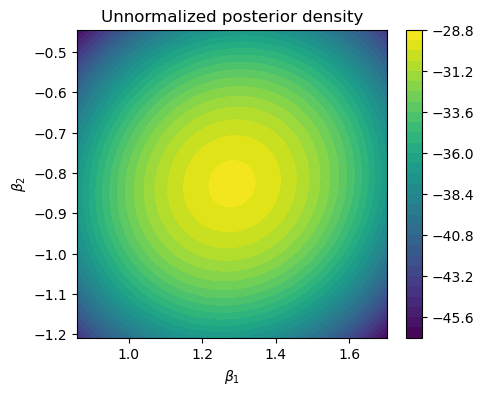


===== K = 1 planar flows =====
epoch    1 | loss = -0.3266
epoch  500 | loss = 1.6986
epoch 1000 | loss = 3.7683
epoch 1500 | loss = 5.6032
epoch 2000 | loss = 7.3368
epoch 2500 | loss = 9.0101
epoch 3000 | loss = 10.6464
epoch 3500 | loss = 12.2600
epoch 4000 | loss = 13.8505
epoch 4500 | loss = 15.4239
epoch 5000 | loss = 16.9890
flow mean:
 tensor([ 1.2854, -0.8317])
true mean:
 tensor([ 1.2808, -0.8266])
flow covariance:
 tensor([[0.0211, 0.0013],
        [0.0013, 0.0184]])
true covariance:
 tensor([[0.0111, 0.0008],
        [0.0008, 0.0091]])
mean error: 0.006829265970736742
cov error : 0.01365749817341566


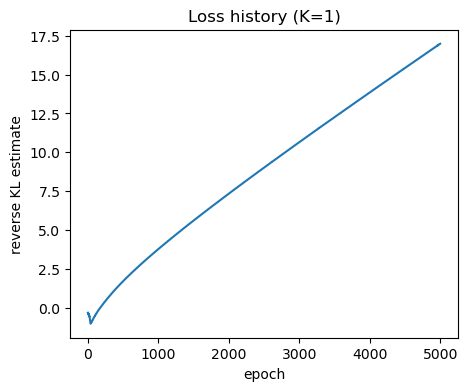

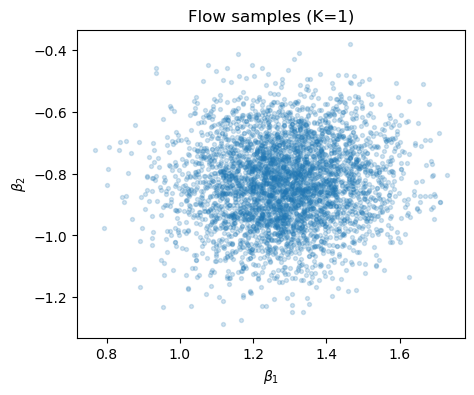

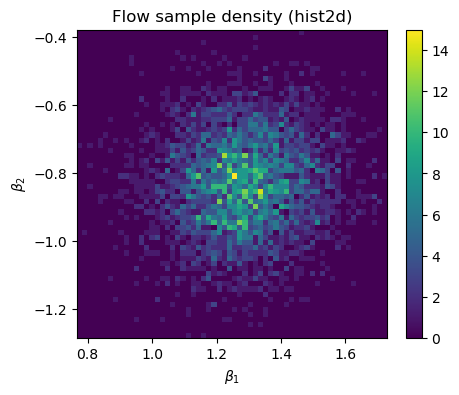


===== K = 4 planar flows =====
epoch    1 | loss = 0.2645
epoch  500 | loss = 1.6986
epoch 1000 | loss = 3.7674
epoch 1500 | loss = 5.6034
epoch 2000 | loss = 7.3361
epoch 2500 | loss = 9.0114
epoch 3000 | loss = 10.6479
epoch 3500 | loss = 12.2596
epoch 4000 | loss = 13.8487
epoch 4500 | loss = 15.4271
epoch 5000 | loss = 16.9887
flow mean:
 tensor([ 1.2777, -0.8286])
true mean:
 tensor([ 1.2808, -0.8266])
flow covariance:
 tensor([[0.0223, 0.0016],
        [0.0016, 0.0175]])
true covariance:
 tensor([[0.0111, 0.0008],
        [0.0008, 0.0091]])
mean error: 0.003737017512321472
cov error : 0.01397031918168068


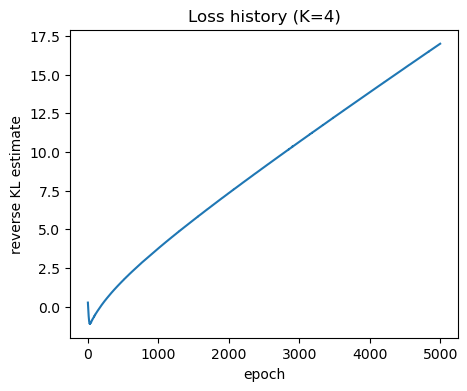

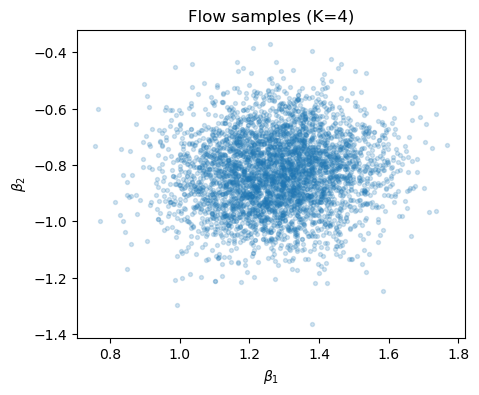

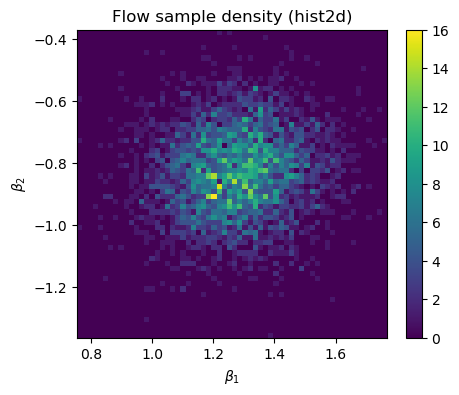


===== K = 8 planar flows =====
epoch    1 | loss = 1.6152
epoch  500 | loss = 1.6986
epoch 1000 | loss = 3.7653
epoch 1500 | loss = 5.6056
epoch 2000 | loss = 7.3352
epoch 2500 | loss = 9.0111
epoch 3000 | loss = 10.6501
epoch 3500 | loss = 12.2577
epoch 4000 | loss = 13.8481
epoch 4500 | loss = 15.4247
epoch 5000 | loss = 16.9902
flow mean:
 tensor([ 1.2855, -0.8184])
true mean:
 tensor([ 1.2808, -0.8266])
flow covariance:
 tensor([[0.0218, 0.0006],
        [0.0006, 0.0170]])
true covariance:
 tensor([[0.0111, 0.0008],
        [0.0008, 0.0091]])
mean error: 0.009459671564400196
cov error : 0.01327192597091198


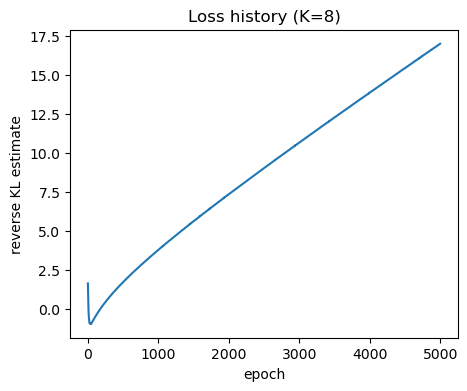

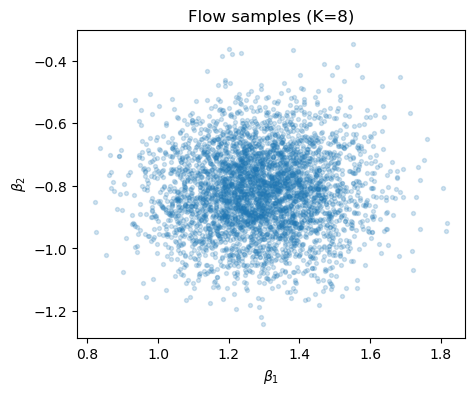

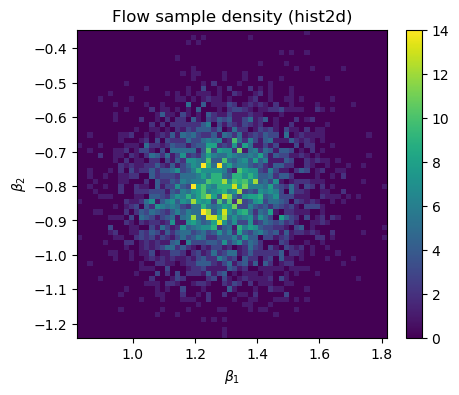


===== K = 16 planar flows =====
epoch    1 | loss = 1.3363
epoch  500 | loss = 1.6979
epoch 1000 | loss = 3.7680
epoch 1500 | loss = 5.6039
epoch 2000 | loss = 7.3349
epoch 2500 | loss = 9.0112
epoch 3000 | loss = 10.6481
epoch 3500 | loss = 12.2599
epoch 4000 | loss = 13.8493
epoch 4500 | loss = 15.4262
epoch 5000 | loss = 16.9891
flow mean:
 tensor([ 1.2939, -0.8252])
true mean:
 tensor([ 1.2808, -0.8266])
flow covariance:
 tensor([[0.0217, 0.0010],
        [0.0010, 0.0172]])
true covariance:
 tensor([[0.0111, 0.0008],
        [0.0008, 0.0091]])
mean error: 0.01315918006002903
cov error : 0.013316141441464424


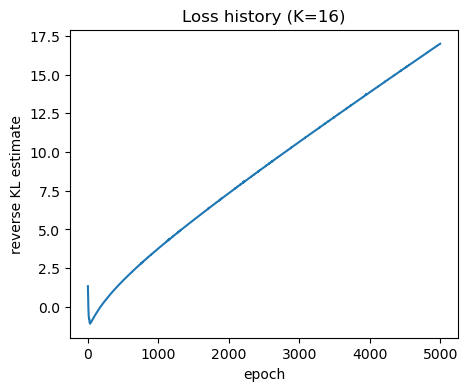

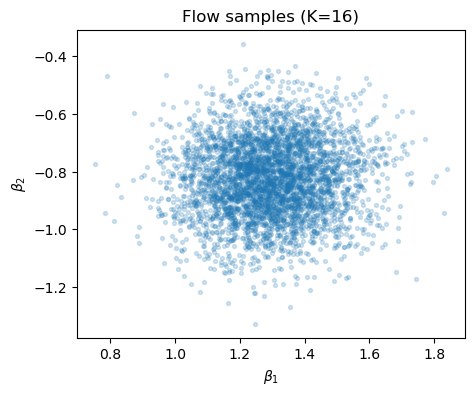

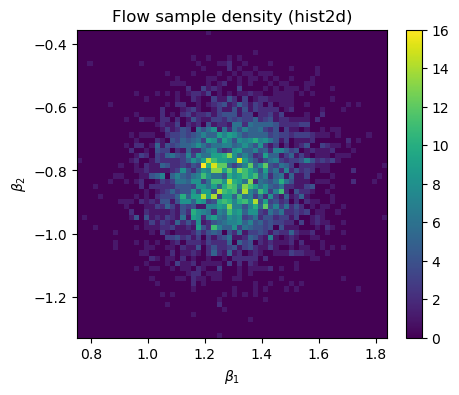

In [12]:
plot_true_posterior(target, mu_post, Sigma_post)

for K in [1, 4, 8, 16]:
    print(f"\n===== K = {K} planar flows =====")
    model = build_planar_nf(dim=p, K=K, target=target, device=device)

    losses = train_nf(
        model,
        epochs=5000,
        num_samples=6000,
        lr=1e-2,
        anneal=True,
    )

    with torch.no_grad():
        betaK, log_q = model.sample(num_samples=4000)

    mu_hat, cov_hat = summarize_flow_samples(betaK)

    print("flow mean:\n", mu_hat)
    print("true mean:\n", mu_post)
    print("flow covariance:\n", cov_hat)
    print("true covariance:\n", Sigma_post)
    print("mean error:", torch.norm(mu_hat - mu_post).item())
    print("cov error :", torch.norm(cov_hat - Sigma_post).item())

    plt.figure(figsize=(5, 4))
    plt.plot(losses)
    plt.title(f"Loss history (K={K})")
    plt.xlabel("epoch")
    plt.ylabel("reverse KL estimate")
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.scatter(betaK[:, 0].cpu(), betaK[:, 1].cpu(), alpha=0.2, s=8)
    plt.title(f"Flow samples (K={K})")
    plt.xlabel(r"$\beta_1$")
    plt.ylabel(r"$\beta_2$")
    plt.show()

    plot_flow_hist2d(betaK)

In [13]:
torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n = 200      # 先不要用 50，先用 200 更稳
p = 100

X = torch.randn(n, p, device=device)

# 真实 beta：前几个分量非零，其余为 0
beta_true = torch.zeros(p, device=device)
beta_true[:5] = torch.tensor([1.5, -0.8, 0.7, -1.2, 0.5], device=device)

sigma2 = torch.tensor(0.5, device=device)

eps = torch.sqrt(sigma2) * torch.randn(n, device=device)
y = X @ beta_true + eps

Sigma = torch.eye(p, device=device)
Sigma_inv = torch.linalg.inv(Sigma)

target = BayesianLinRegTarget(X, y, sigma2, Sigma_inv).to(device)
mu_post, Sigma_post = posterior_closed_form(X, y, sigma2, Sigma)

In [14]:
def summarize_highdim_results(beta_samples, mu_post, Sigma_post, k_show=10):
    mu_hat, cov_hat = summarize_flow_samples(beta_samples)

    mean_abs_err = torch.norm(mu_hat - mu_post).item()
    cov_abs_err = torch.norm(cov_hat - Sigma_post).item()

    mean_rel_err = (torch.norm(mu_hat - mu_post) / torch.norm(mu_post)).item()
    cov_rel_err = (torch.norm(cov_hat - Sigma_post) / torch.norm(Sigma_post)).item()

    print("mean abs error:", mean_abs_err)
    print("mean rel error:", mean_rel_err)
    print("cov  abs error:", cov_abs_err)
    print("cov  rel error:", cov_rel_err)

    print("\nfirst few coordinates of posterior mean:")
    print("flow mean[:k] =", mu_hat[:k_show])
    print("true mean[:k] =", mu_post[:k_show])

    return mu_hat, cov_hat


===== p = 100, K = 1 planar flows =====
epoch    1 | loss = 108.4933
epoch  500 | loss = 306.2616
epoch 1000 | loss = 251.6884
epoch 1500 | loss = 209.9187
epoch 2000 | loss = 189.6212
epoch 2500 | loss = 181.2514
epoch 3000 | loss = 180.8094
epoch 3500 | loss = 184.5705
epoch 4000 | loss = 190.2974
epoch 4500 | loss = 197.7060
epoch 5000 | loss = 204.6593
mean abs error: 0.01961548812687397
mean rel error: 0.008096301928162575
cov  abs error: 0.05107531696557999
cov  rel error: 0.7156057953834534

first few coordinates of posterior mean:
flow mean[:k] = tensor([ 1.5524, -0.8559,  0.7169, -1.0851,  0.5911, -0.0076,  0.0661, -0.0549,
        -0.1188,  0.0206])
true mean[:k] = tensor([ 1.5533, -0.8565,  0.7152, -1.0886,  0.5880, -0.0067,  0.0641, -0.0564,
        -0.1176,  0.0247])


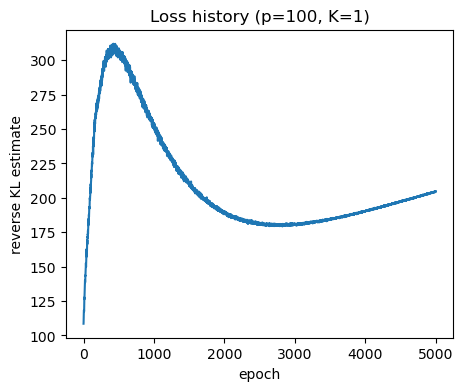


===== p = 100, K = 4 planar flows =====
epoch    1 | loss = 280.5513
epoch  500 | loss = 307.6852
epoch 1000 | loss = 257.0623
epoch 1500 | loss = 212.7361
epoch 2000 | loss = 190.7983
epoch 2500 | loss = 181.0718
epoch 3000 | loss = 179.7914
epoch 3500 | loss = 183.5086
epoch 4000 | loss = 189.1762
epoch 4500 | loss = 196.0325
epoch 5000 | loss = 203.2547
mean abs error: 0.02362748607993126
mean rel error: 0.00975225679576397
cov  abs error: 0.05069151520729065
cov  rel error: 0.710228443145752

first few coordinates of posterior mean:
flow mean[:k] = tensor([ 1.5512, -0.8565,  0.7119, -1.0893,  0.5884, -0.0090,  0.0652, -0.0565,
        -0.1222,  0.0242])
true mean[:k] = tensor([ 1.5533, -0.8565,  0.7152, -1.0886,  0.5880, -0.0067,  0.0641, -0.0564,
        -0.1176,  0.0247])


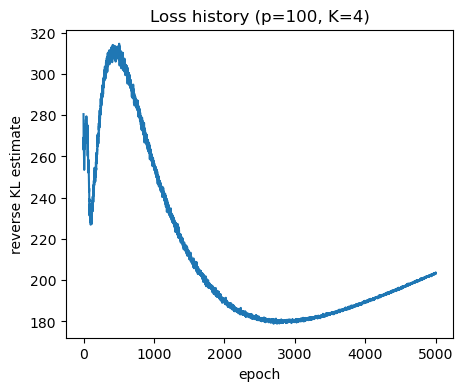


===== p = 100, K = 8 planar flows =====
epoch    1 | loss = 553.9846
epoch  500 | loss = 311.0768
epoch 1000 | loss = 254.8149
epoch 1500 | loss = 212.9653
epoch 2000 | loss = 190.2136
epoch 2500 | loss = 180.4920
epoch 3000 | loss = 179.7640
epoch 3500 | loss = 182.7668
epoch 4000 | loss = 188.5369
epoch 4500 | loss = 194.7920
epoch 5000 | loss = 201.7756
mean abs error: 0.030873797833919525
mean rel error: 0.012743175029754639
cov  abs error: 0.05001835897564888
cov  rel error: 0.7007969617843628

first few coordinates of posterior mean:
flow mean[:k] = tensor([ 1.5556, -0.8584,  0.7172, -1.0915,  0.5870, -0.0050,  0.0615, -0.0573,
        -0.1196,  0.0230])
true mean[:k] = tensor([ 1.5533, -0.8565,  0.7152, -1.0886,  0.5880, -0.0067,  0.0641, -0.0564,
        -0.1176,  0.0247])


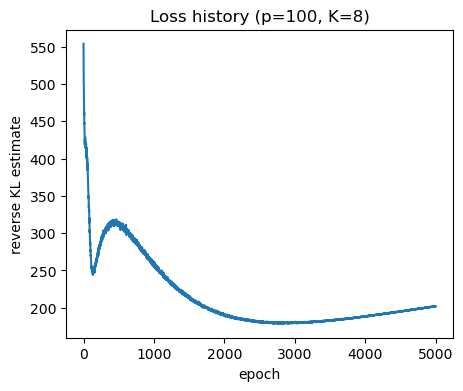

In [16]:
for K in [1, 4, 8]:
    print(f"\n===== p = {p}, K = {K} planar flows =====")
    model = build_planar_nf(dim=p, K=K, target=target, device=device)

    losses = train_nf(
        model,
        epochs=5000,
        num_samples=1024,
        lr=1e-3,
        anneal=True,
    )

    with torch.no_grad():
        betaK, _ = model.sample(num_samples=20000)

    mu_hat, cov_hat = summarize_highdim_results(betaK, mu_post, Sigma_post, k_show=10)

    plt.figure(figsize=(5, 4))
    plt.plot(losses)
    plt.title(f"Loss history (p={p}, K={K})")
    plt.xlabel("epoch")
    plt.ylabel("reverse KL estimate")
    plt.show()